# Visualisation with seaborn

`seaborn` is a statistical graphics library, based on matplotlib, that simplifies many common visualisation types. seaborn provides a high-level interface for making attractive and informative statistical graphics. With data that requires aggregation or summarization before making a plot, using the seaborn package can make things much simpler.   
   
Tip: Just importing seaborn modifies the default matplotlib color schemes and plot styles and improves readability and aesthetics. Even if you do not use the seaborn API, you may prefer to import seaborn as a simple way to improve the visual aesthetics of general matplotlib plots.

In [4]:
#import packages
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
#increase figure size
plt.rc('figure', figsize=(10,10))

In [6]:
#read rainfall data
rainfall_perth = pd.read_csv("https://raw.githubusercontent.com/AustralianSDAF/python-data-visualisation/main/perth-rainfall-data.csv")

In [7]:
# view the first 5 rows of the rainfall_perth DataFrame
rainfall_perth.head()

,Product code,Station number,Year,Month,Monthly Precipitation Total (millimetres),Quality
0,IDCJAC0001,9225,1993,2,27.6,Y
1,IDCJAC0001,9225,1993,3,5.8,Y
2,IDCJAC0001,9225,1993,4,14.6,Y
3,IDCJAC0001,9225,1993,5,129.6,Y
4,IDCJAC0001,9225,1993,6,64.4,Y


## Line plot

Plotting functions in seaborn take a `data` arguments, which can be a pandas DataFrame. Here we filter the rainfall data for the Month of August for all years. The `rainfall_august` DataFrame is then passed to the `lineplot()` as the `data` argument to plot a line plot.

In [27]:
rainfall_august = rainfall_perth.query("Month == 8")
rainfall_august.head()

,Product code,Station number,Year,Month,Monthly Precipitation Total (millimetres),Quality
6,IDCJAC0001,9225,1993,8,158.4,Y
17,IDCJAC0001,9225,1994,8,164.2,Y
29,IDCJAC0001,9225,1995,8,83.8,Y
41,IDCJAC0001,9225,1996,8,123.6,Y
53,IDCJAC0001,9225,1997,8,119.2,Y


<AxesSubplot:xlabel='Year', ylabel='Monthly Precipitation Total (millimetres)'>

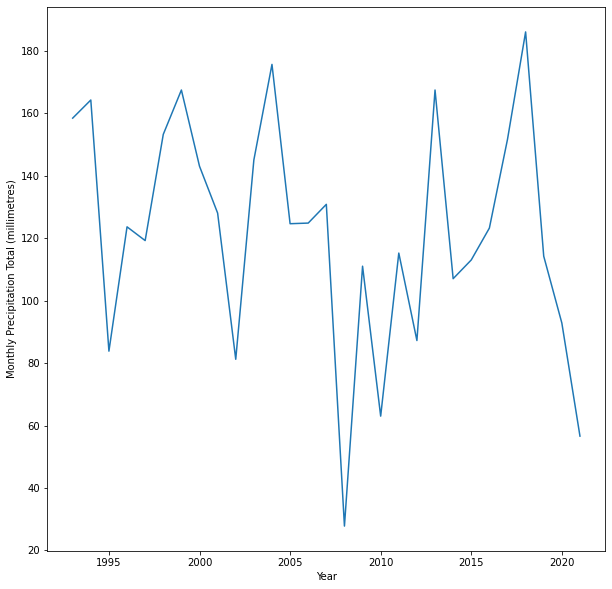

In [9]:
sns.lineplot(data=rainfall_august, x="Year", y="Monthly Precipitation Total (millimetres)")

## Bar plot

To make bar plots using seaborn, the `barplot()` function can be used. Here we use the `orient='h'` parameter to make the plot horizontal.

<AxesSubplot:xlabel='Monthly Precipitation Total (millimetres)', ylabel='Year'>

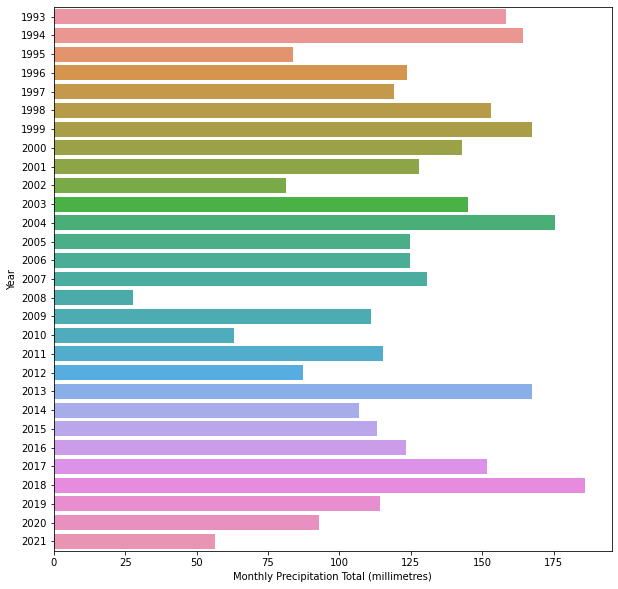

In [10]:
sns.barplot(data=rainfall_august, y="Year", x="Monthly Precipitation Total (millimetres)", orient='h')

seaborn makes plotting categorical data very easy. In the following example, we filter the original `rainfall_perth` DataFrame for the rainfall data for months of July and August only. We then use the `barplot()` to plot the resulting DataFrame. `seaborn.barplot` has a `hue` option that enables us to split by an additional categorical value, in this case by the `Month`.

In [30]:
rainfall_august_july = rainfall_perth.query("Month == 8 | Month == 7")

# rainfall_august_july = rainfall_perth[(rainfall_perth["Month"] == 8) | (rainfall_perth["Month"] == 9)]
rainfall_august_july.head()

,Product code,Station number,Year,Month,Monthly Precipitation Total (millimetres),Quality
5,IDCJAC0001,9225,1993,7,123.2,Y
6,IDCJAC0001,9225,1993,8,158.4,Y
16,IDCJAC0001,9225,1994,7,167.4,Y
17,IDCJAC0001,9225,1994,8,164.2,Y
28,IDCJAC0001,9225,1995,7,278.6,Y


<AxesSubplot:xlabel='Monthly Precipitation Total (millimetres)', ylabel='Year'>

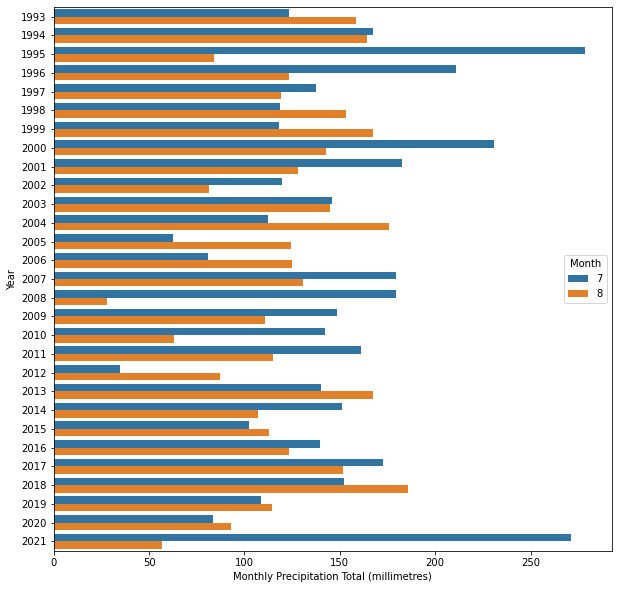

In [31]:
#Plot a bar plot with each individual month as a separate bar.
sns.barplot(data=rainfall_august_july, y="Year", x="Monthly Precipitation Total (millimetres)", hue='Month', orient='h')

## Scatter Plot

The `.scatterplot()` method is used to make scatterplots. Similarly, the `hue` parameter can be used to split by an additional categorical value.

<AxesSubplot:xlabel='Year', ylabel='Monthly Precipitation Total (millimetres)'>

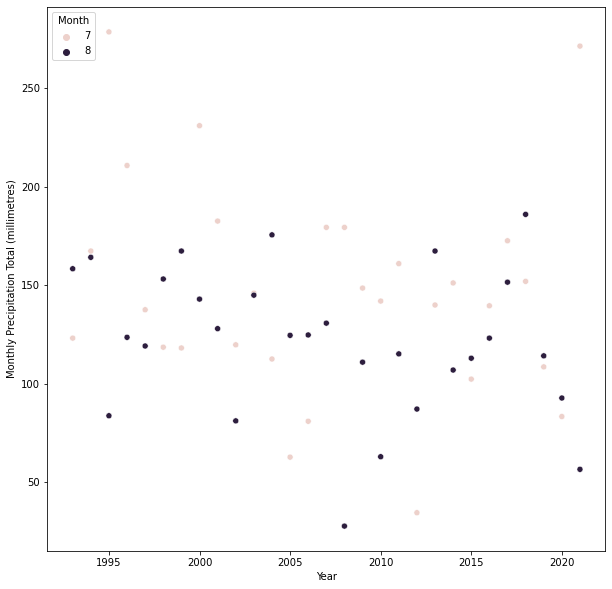

In [ ]:
sns.scatterplot(data=rainfall_august_july, x="Year", y="Monthly Precipitation Total (millimetres)", hue='Month')

## Scatter plot matrix

When exploring data, it can be useful to look at the scatter plots among a group of variables to determine how closely variables are related. This type of plot is known as _pairs_ plot or _scatter plot matrix_.   

Seaborn has an intuitive `pairplot` function that plots the scatter plot matrix. Additionally, the `pairplot` function, by default, places histograms or density estimated of each variable along the diagonal.

In [32]:
# Read the 2008 Perth weather info
perth_weather_08 = pd.read_csv('https://raw.githubusercontent.com/AustralianSDAF/python-data-visualisation/main/perth-detailed-weather-08.csv')

In [33]:
# Drop columns we do not need.
perth_weather_08.drop(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday',  'RainTomorrow' ], axis=1, inplace=True)

Create a scatter plot matrix using `pairplot`. The `plot_kws` argument allows us to pass configuration options to the individual plotting calls on the off-diagonal elements.

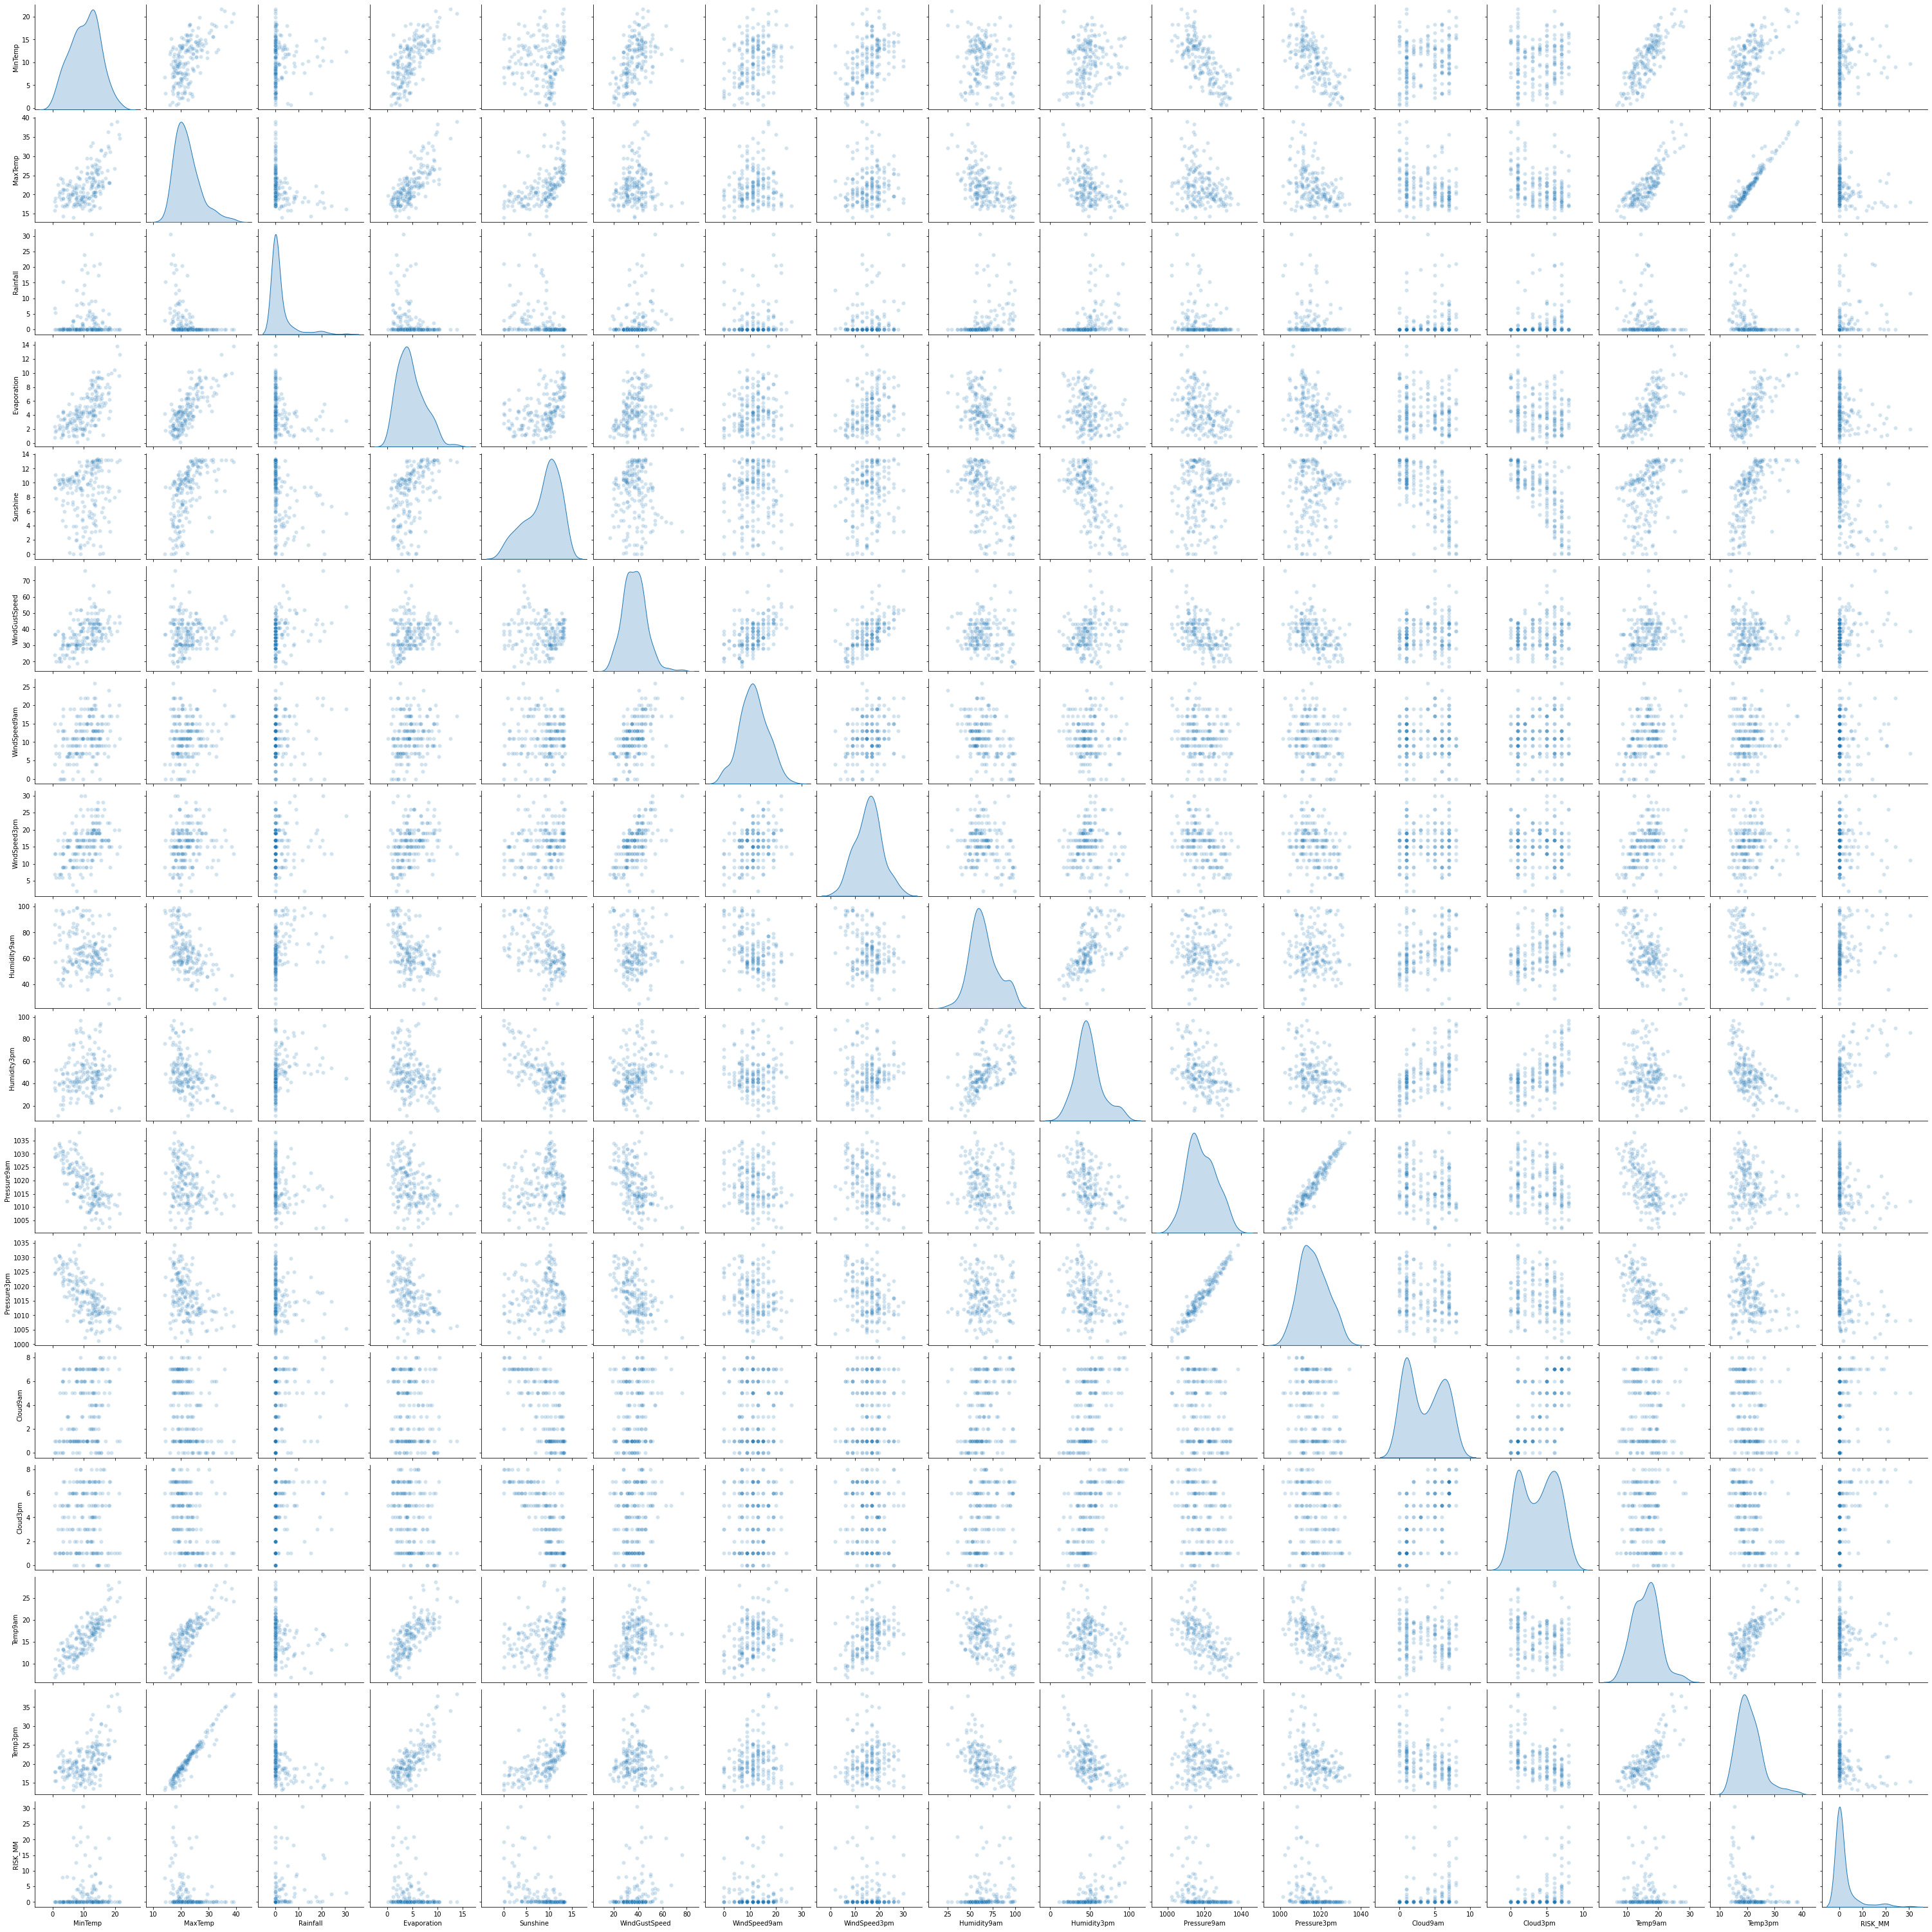

In [34]:
sns.pairplot(perth_weather_08, diag_kind='kde', plot_kws={'alpha': 0.2})